# Arabic Handwritten Characters Classifier

## Data Loading

In [112]:
import pandas as pd

train_labels = pd.read_csv('data/labels/train.csv', header=None) - 1
test_labels = pd.read_csv('data/labels/test.csv', header=None) - 1

In [113]:
train_labels.head().values

array([[0],
       [0],
       [0],
       [0],
       [0]])

In [114]:
train_labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 13440 entries, 0 to 13439
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       13440 non-null  int64
dtypes: int64(1)
memory usage: 105.1 KB


In [115]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    'data/images/train',
    labels=train_labels[0].values.tolist(),
    seed=42,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    image_size=(32, 32),
    batch_size=32,
    color_mode='grayscale',
    verbose=True
)

Found 13440 files belonging to 28 classes.
Using 10752 files for training.


In [116]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    'data/images/train',
    labels=train_labels[0].values.tolist(),
    seed=42,
    shuffle=True,
    validation_split=0.2,
    subset='validation',
    image_size=(32, 32),
    batch_size=32,
    color_mode='grayscale',
    verbose=True
)

Found 13440 files belonging to 28 classes.
Using 2688 files for validation.


In [117]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    'data/images/test',
    labels=test_labels[0].values.tolist(),
    seed=42,
    shuffle=True,
    image_size=(32, 32),
    batch_size=32,
    color_mode='grayscale',
    verbose=True
)

Found 3360 files belonging to 28 classes.


## Visualization

In [118]:
class_names = ['أ', 'ب', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ي']

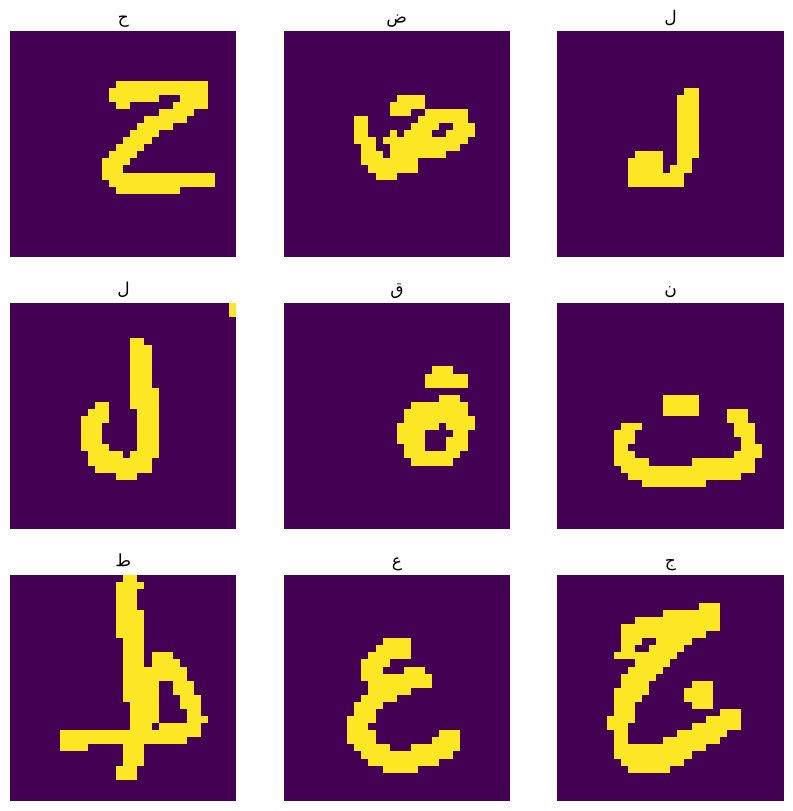

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## Training

### Model from Scratch

#### Training

In [138]:
model = tf.keras.Sequential([
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=64, kernel_size=5, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.GlobalMaxPooling2D(),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(28, activation='softmax')
])

In [139]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

In [141]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds
)

Epoch 1/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 57s 170ms/step - accuracy: 0.3060 - loss: 2.3206 - val_accuracy: 0.7124 - val_loss: 1.2359
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 62s 183ms/step - accuracy: 0.5082 - loss: 1.5620 - val_accuracy: 0.7939 - val_loss: 0.7880
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 62s 183ms/step - accuracy: 0.6296 - loss: 1.1777 - val_accuracy: 0.8553 - val_loss: 0.5851
Epoch 4/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 61s 182ms/step - accuracy: 0.7020 - loss: 0.9661 - val_accuracy: 0.9070 - val_loss: 0.3912
Epoch 5/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 62s 184ms/step - accuracy: 0.7453 - loss: 0.8253 - val_accuracy: 0.9051 - val_loss: 0.3615
Epoch 6/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 62s 186ms/step - accuracy: 0.7800 - loss: 0.7183 - val_accuracy: 0.9129 - val_loss: 0.3015
Epoch 7/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 67s 198ms/step - accuracy: 0.7991 - loss: 0.6487 - val_accuracy: 0.9293 - val_loss: 0.2570
Epoch 8/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 67s 200ms/step - accuracy: 0.8159 - loss: 0

The Model takes around 10 minutes to train getting an accuracy of around 92% on the validation set.

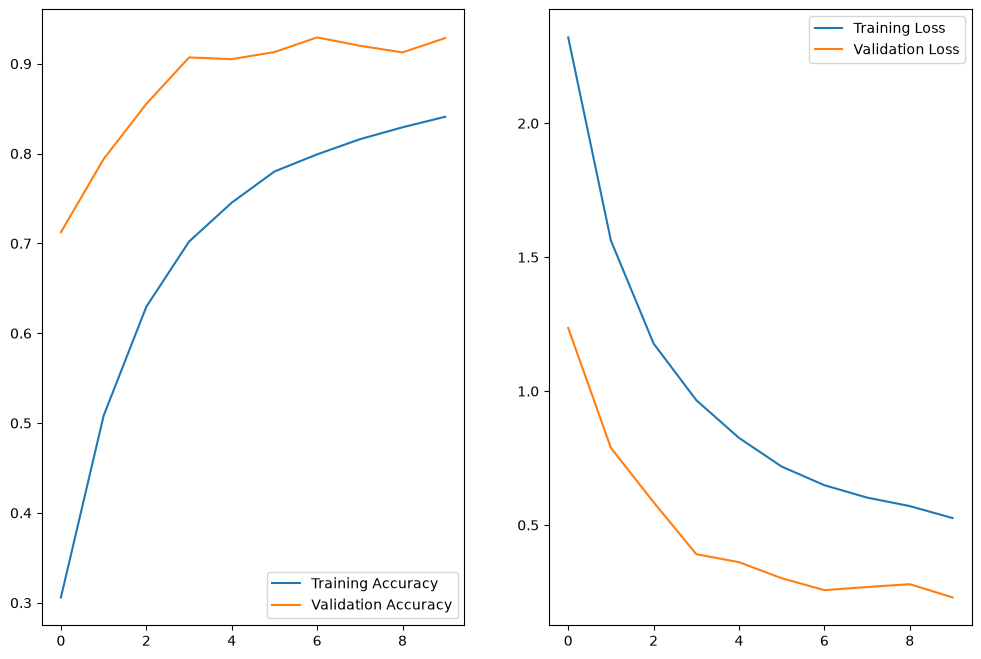

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(12,8))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].legend()

plt.show()

#### Evaluating

In [195]:
images, labels = next(iter(test_ds))
new_images = images[:9]
new_labels = labels[:9]

new_labels

<tf.Tensor: shape=(9,), dtype=int32, numpy=array([ 2, 12, 19,  1, 24, 26, 18, 11,  3], dtype=int32)>

In [196]:
import numpy as np

predictions = np.argmax(model.predict(new_images), axis=1)

predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


array([ 2, 12, 19,  1, 24, 26, 18, 11,  3])

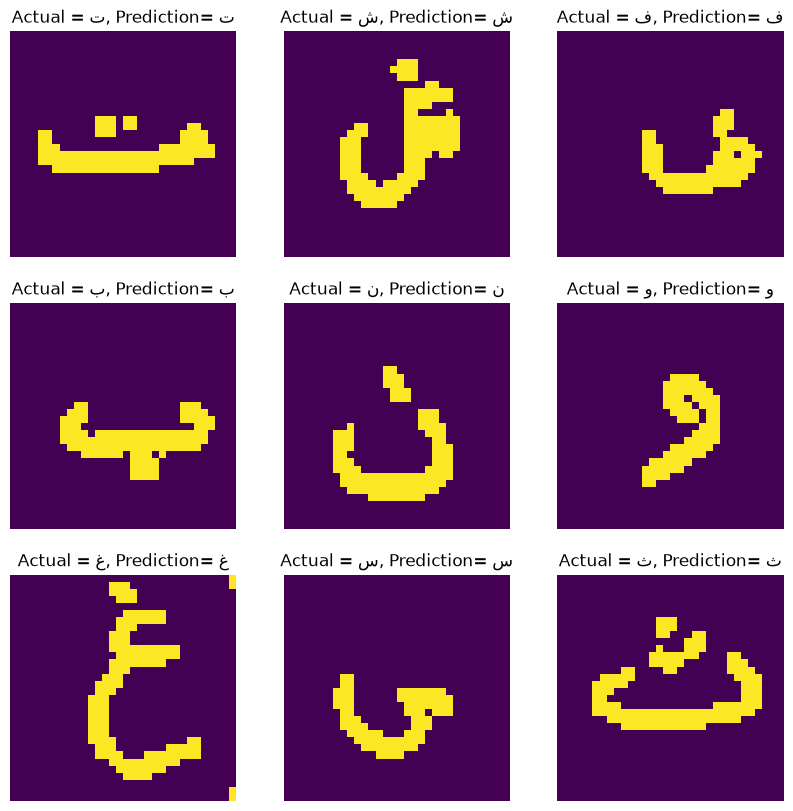

In [197]:
plt.figure(figsize=(10, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(new_images[i].numpy().astype("uint8"))
    plt.title(f'Actual = {class_names[new_labels[i]]}, Prediction= {class_names[predictions[i]]}')
    plt.axis("off")

#### Saving

In [194]:
model.save('model_1_from_scratch.keras')

### Pretrained Model

### Pretrained Model with Data Augmentation